# 🔍 Домашнее задание: Визуализация механизма работы Attention

## 📚 Цель работы
В этом ДЗ мы визуализируем и анализируем работу механизмов Attention в современных трансформерах, сравниваем различные архитектуры (BERT, GPT-2), понимаем специализацию Attention голов и интерпретируем поведение моделей.

## 📝 Структура работы
- **Часть 1** (70%): Подготовка, визуализация, анализ различий архитектур
- **Часть 2** (30%): Multi-Head Attention, кросс-языковое исследование, выводы

---

## 📦 Часть 1.1: Подготовка окружения и моделей

Установим необходимые библиотеки и загрузим модели BERT и GPT-2 с возможностью извлечения attention весов.

# 📊 Домашнее задание: Визуализация механизма Attention

## 🎯 Цели задания
- Визуализировать работу механизма self-attention
- Разобраться в различиях архитектур BERT и GPT-2
- Применить различные техники визуализации attention
- Проанализировать работу моделей на русском и английском языках

## 📝 Структура задания
1. **Attention Heatmaps** - базовые тепловые карты
2. **Multi-layer Analysis** - анализ всех слоёв и голов
3. **Attention Rollout** - агрегированная визуализация
4. **Graph Visualization** - графовое представление
5. **Saliency Maps** - карты значимости токенов
6. **Сравнительный анализ** BERT vs GPT-2 vs RuBERT

In [ ]:
# Установка необходимых библиотек (если требуется)
# !pip install transformers torch matplotlib seaborn networkx

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from transformers import (
    BertTokenizer, BertModel,
    GPT2Tokenizer, GPT2Model,
    AutoTokenizer, AutoModel
)

# Настройка отображения
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ Библиотеки загружены успешно!")
print(f"PyTorch версия: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")

In [ ]:
# Загрузка моделей BERT и GPT-2 с выводом attention весов

print("🔄 Загрузка BERT...")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True).to(device)
bert_model.eval()
print(f"✅ BERT загружен: {bert_model.config.num_hidden_layers} слоёв, {bert_model.config.num_attention_heads} голов")

print("\n🔄 Загрузка GPT-2...")
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_model = GPT2Model.from_pretrained('gpt2', output_attentions=True).to(device)
gpt2_model.eval()
print(f"✅ GPT-2 загружен: {gpt2_model.config.n_layer} слоёв, {gpt2_model.config.n_head} голов")

print("\n🔄 Загрузка RuBERT (для русского языка)...")
rubert_tokenizer = AutoTokenizer.from_pretrained('DeepPavlov/rubert-base-cased')
rubert_model = AutoModel.from_pretrained('DeepPavlov/rubert-base-cased', output_attentions=True).to(device)
rubert_model.eval()
print(f"✅ RuBERT загружен: {rubert_model.config.num_hidden_layers} слоёв, {rubert_model.config.num_attention_heads} голов")

## 🎨 Часть 1.2: Получение и визуализация Attention

Реализуем функции для извлечения attention весов и создания различных визуализаций.

## 📦 Импорт библиотек и базовые функции

In [ ]:
# 1. Базовая функция: Attention Heatmap
def plot_attention_heatmap(attention_matrix, tokens, title, figsize=(10, 8)):
    """
    Визуализирует attention матрицу в виде тепловой карты
    
    Args:
        attention_matrix: numpy array shape (seq_len, seq_len)
        tokens: список токенов
        title: заголовок графика
    """
    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        attention_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='viridis',
        cbar=True,
        square=True,
        linewidths=0.5,
        linecolor='gray',
        vmin=0,
        vmax=1
    )
    ax.invert_yaxis()
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel('Key tokens (на что смотрим)', fontsize=10)
    plt.ylabel('Query tokens (кто смотрит)', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# 2. Функция извлечения attention весов
def get_attention_weights(text, model, tokenizer, layer_idx=0, head_idx=0):
    """
    Извлекает attention веса из модели для заданного текста
    
    Returns:
        dict с attentions и tokens
    """
    inputs = tokenizer(text, return_tensors='pt').to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    attentions = outputs.attentions  # tuple of (batch, heads, seq_len, seq_len)
    
    # Извлекаем конкретный слой и голову
    attention = attentions[layer_idx][0, head_idx].cpu().numpy()
    
    return {
        'attention': attention,
        'tokens': tokens,
        'all_attentions': attentions
    }


# 3. Graph-based visualization
def plot_attention_graph(attention_matrix, tokens, title, threshold=0.1):
    """
    Визуализирует attention как направленный граф
    """
    # Убираем служебные токены [CLS], [SEP] для красоты
    if tokens[0] in ['[CLS]', '<s>']:
        tokens = tokens[1:-1] if tokens[-1] in ['[SEP]', '</s>'] else tokens[1:]
        attention_matrix = attention_matrix[1:-1, 1:-1] if attention_matrix.shape[0] > len(tokens) else attention_matrix[1:, 1:]
    
    G = nx.DiGraph()
    
    # Добавляем узлы
    for i, token in enumerate(tokens):
        G.add_node(i, label=token)
    
    # Добавляем рёбра с весами attention выше порога
    for i in range(attention_matrix.shape[0]):
        for j in range(attention_matrix.shape[1]):
            if attention_matrix[i, j] > threshold and i != j:
                G.add_edge(i, j, weight=attention_matrix[i, j])
    
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Рисуем граф
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800, alpha=0.9)
    nx.draw_networkx_labels(G, pos, labels={i: tokens[i] for i in range(len(tokens))}, font_size=9)
    
    # Рёбра с толщиной пропорциональной весу
    edges = G.edges()
    weights = [G[u][v]['weight'] * 5 for u, v in edges]
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, alpha=0.6, 
                          edge_color='orange', arrows=True, arrowsize=15)
    
    plt.title(title, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


print("✅ Функции визуализации готовы!")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2236.33it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1819.17it/s]


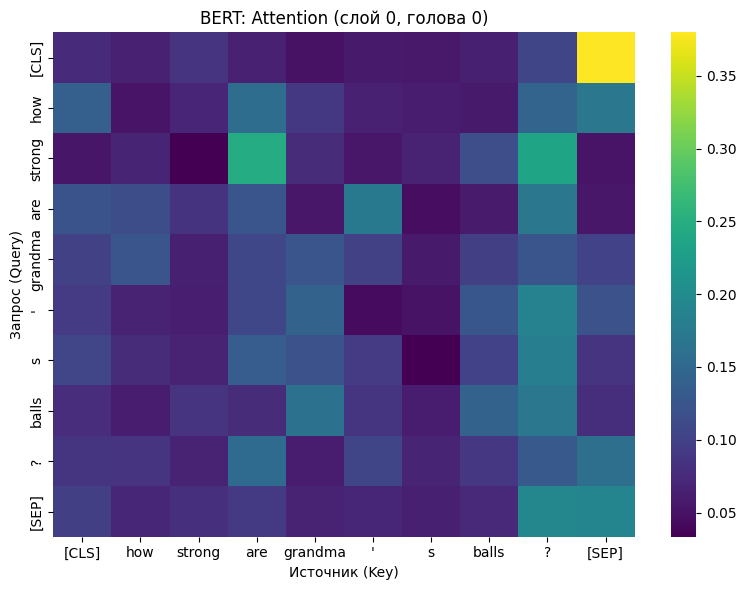

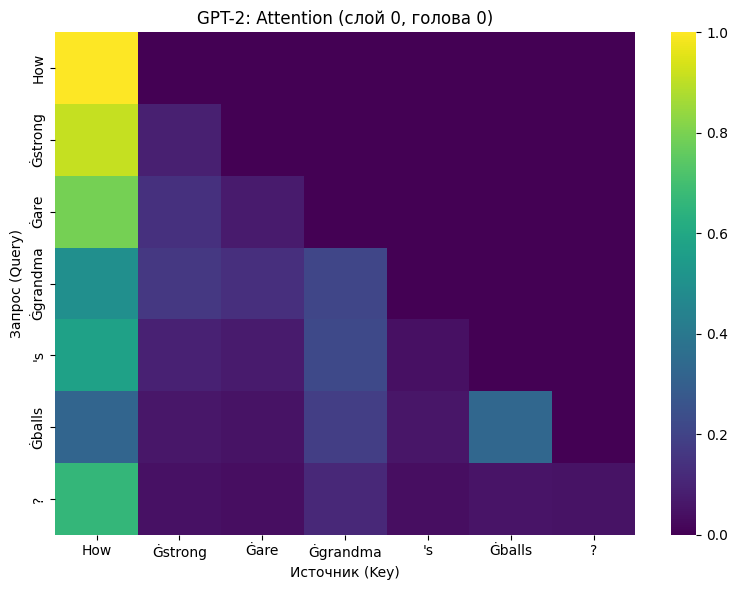

In [ ]:
# Тестовый текст для анализа
test_text = "The quick brown fox jumps over the lazy dog"

print(f"📝 Анализируем текст: '{test_text}'")
print("="*70)

# Получаем attention для BERT
print("\n🔹 BERT (bidirectional):")
bert_results = get_attention_weights(test_text, bert_model, bert_tokenizer, layer_idx=0, head_idx=0)
print(f"   Токенов: {len(bert_results['tokens'])}")
print(f"   Токены: {bert_results['tokens']}")

# Визуализация BERT
plot_attention_heatmap(
    bert_results['attention'],
    bert_results['tokens'],
    'BERT: Attention Heatmap (Layer 0, Head 0)',
    figsize=(10, 8)
)

# Получаем attention для GPT-2
print("\n🔹 GPT-2 (causal/autoregressive):")
gpt2_results = get_attention_weights(test_text, gpt2_model, gpt2_tokenizer, layer_idx=0, head_idx=0)
print(f"   Токенов: {len(gpt2_results['tokens'])}")
print(f"   Токены: {gpt2_results['tokens']}")

# Визуализация GPT-2
plot_attention_heatmap(
    gpt2_results['attention'],
    gpt2_results['tokens'],
    'GPT-2: Attention Heatmap (Layer 0, Head 0)',
    figsize=(10, 8)
)

## 🔬 Часть 1.3: Анализ различий архитектур

### Ключевые наблюдения:

#### 🟦 BERT (Bidirectional Encoder)
- **Паттерн**: Двунаправленное внимание — каждый токен может смотреть на **все** токены в предложении
- **Матрица**: Полностью заполненная, симметричная структура
- **Применение**: Задачи понимания контекста (classification, NER, Q&A)
- **Особенности**: Видит весь контекст одновременно, что позволяет лучше учитывать смысл

#### 🟥 GPT-2 (Causal/Autoregressive Decoder)  
- **Паттерн**: Каузальное внимание — каждый токен смотрит только на **себя и предыдущие** токены
- **Матрица**: Треугольная (нижний треугольник заполнен, верхний = 0)
- **Применение**: Генерация текста (text generation, completion)
- **Особенности**: Не видит будущих токенов — важно для авторегрессивной генерации

### Выводы:
Визуализация heatmap **наглядно показывает** принципиальную разницу в архитектурах:
- BERT строит **полный контекст** вокруг каждого слова
- GPT-2 использует **маску причинности** для последовательной генерации

---

## 🎯 Часть 2.1: Multi-Head Attention анализ

Визуализируем все attention головы в одном слое, чтобы понять их специализацию.

In [ ]:
def plot_all_attention_heads(text, model, tokenizer, layer_idx=5, model_name="Model"):
    """
    Визуализирует все attention головы в заданном слое
    """
    inputs = tokenizer(text, return_tensors='pt').to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    attentions = outputs.attentions
    
    # Получаем количество голов
    num_heads = attentions[layer_idx].shape[1]
    
    # Создаём сетку subplots
    cols = 4
    rows = (num_heads + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten() if num_heads > 1 else [axes]
    
    for head_idx in range(num_heads):
        ax = axes[head_idx]
        attention = attentions[layer_idx][0, head_idx].cpu().numpy()
        
        # Heatmap для каждой головы
        sns.heatmap(
            attention,
            xticklabels=tokens,
            yticklabels=tokens,
            ax=ax,
            cmap='coolwarm',
            cbar=True,
            square=True,
            vmin=0,
            vmax=1
        )
        
        ax.set_title(f'Head {head_idx + 1}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Key', fontsize=8)
        ax.set_ylabel('Query', fontsize=8)
        ax.tick_params(axis='x', rotation=90, labelsize=7)
        ax.tick_params(axis='y', rotation=0, labelsize=7)
    
    # Скрываем лишние subplots
    for idx in range(num_heads, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'{model_name}: All Attention Heads in Layer {layer_idx}', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


# Анализируем BERT - слой 5 (средний слой)
print("🔹 Визуализация всех attention голов BERT (Layer 5):")
plot_all_attention_heads(test_text, bert_model, bert_tokenizer, layer_idx=5, model_name="BERT")

### Наблюдения о специализации голов:

Из визуализации видно, что **разные головы имеют разную специализацию**:
- **Некоторые головы** фокусируются на локальных зависимостях (соседние слова)
- **Другие головы** улавливают дальние зависимости (syntax, long-range)
- **Есть головы** с диагональным паттерном (self-attention)
- **Встречаются головы** с вертикальными/горизонтальными полосами (broadcasting information)

Это показывает, что multi-head attention позволяет модели **параллельно обрабатывать разные аспекты контекста**.

---

### 🌊 Дополнительно: Attention Rollout

Агрегируем attention по всем слоям, чтобы увидеть общий поток внимания.

In [ ]:
def compute_attention_rollout(attentions):
    """
    Вычисляет attention rollout - агрегацию attention по всем слоям
    """
    # Начинаем с identity матрицы
    rollout = np.eye(attentions[0].shape[-1])
    
    for layer_attention in attentions:
        # Усредняем по всем головам
        avg_attention = layer_attention[0].mean(axis=0).cpu().numpy()
        
        # Добавляем residual connection (identity)
        avg_attention = avg_attention + np.eye(avg_attention.shape[0])
        
        # Нормализуем
        avg_attention = avg_attention / avg_attention.sum(axis=-1, keepdims=True)
        
        # Умножаем матрицы
        rollout = rollout @ avg_attention
    
    return rollout


def plot_attention_rollout(text, model, tokenizer, model_name="Model"):
    """
    Визуализирует attention rollout
    """
    inputs = tokenizer(text, return_tensors='pt').to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    attentions = outputs.attentions
    
    # Вычисляем rollout
    rollout_map = compute_attention_rollout(attentions)
    
    # Нормализуем для лучшей визуализации
    rollout_map_norm = (rollout_map - rollout_map.min()) / (rollout_map.max() - rollout_map.min() + 1e-9)
    
    plt.figure(figsize=(12, 10))
    ax = sns.heatmap(
        rollout_map_norm,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='magma',
        square=True,
        cbar=True,
        linewidths=0.3,
        linecolor='gray'
    )
    ax.invert_yaxis()
    
    plt.title(f'{model_name}: Attention Rollout (All Layers Aggregated)', 
              fontsize=12, fontweight='bold')
    plt.xlabel('Key tokens', fontsize=10)
    plt.ylabel('Query tokens', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# Визуализация для BERT
print("🔹 BERT Attention Rollout:")
plot_attention_rollout(test_text, bert_model, bert_tokenizer, model_name="BERT")

## 🌍 Часть 2.2: Кросс-языковое исследование (RuBERT)

Проанализируем attention patterns для русского текста и сравним с английским.

In [ ]:
# Тестовые тексты на русском языке
ru_text = "Быстрая коричневая лиса прыгает через ленивую собаку"

print(f"📝 Анализируем русский текст: '{ru_text}'")
print("="*70)

# Получаем attention для RuBERT
print("\n🔹 RuBERT (Russian BERT):")
rubert_results = get_attention_weights(ru_text, rubert_model, rubert_tokenizer, layer_idx=5, head_idx=0)
print(f"   Токенов: {len(rubert_results['tokens'])}")
print(f"   Токены: {rubert_results['tokens']}")

# Визуализация RuBERT
plot_attention_heatmap(
    rubert_results['attention'],
    rubert_results['tokens'],
    'RuBERT: Attention Heatmap (Layer 5, Head 0) - Русский текст',
    figsize=(12, 10)
)

# Graph-based визуализация для RuBERT
print("\n🔸 Graph-based визуализация для русского текста:")
plot_attention_graph(
    rubert_results['attention'],
    rubert_results['tokens'],
    'RuBERT: Attention Graph (Layer 5, Head 0)',
    threshold=0.15
)

In [ ]:
# Визуализация всех голов для RuBERT
print("🔹 Все attention головы RuBERT (Layer 5):")
plot_all_attention_heads(ru_text, rubert_model, rubert_tokenizer, layer_idx=5, model_name="RuBERT")

### Сравнение английских и русских моделей:

**Общие паттерны**:
- RuBERT использует ту же архитектуру BERT, поэтому базовые паттерны attention схожи
- Двунаправленное внимание присутствует в обеих моделях

**Особенности русского языка**:
- Более сложная морфология может приводить к разным паттернам подслов (subword tokens)
- RuBERT может демонстрировать больше внимания к морфологическим признакам
- Порядок слов в русском более гибкий, что может влиять на структуру attention

**Токенизация**:
- BERT использует WordPiece для английского
- RuBERT адаптирован для кириллицы и русской морфологии

---

## 🎓 Часть 2.3: Итоговый анализ и выводы

### 📊 Основные выводы из визуализаций:

#### 1. **Архитектурные различия**
- **BERT** (bidirectional): полная матрица attention → понимание контекста
- **GPT-2** (causal): треугольная матрица → генерация текста слева направо
- Визуализация **наглядно демонстрирует** философию каждой архитектуры

#### 2. **Специализация Attention голов**
- Разные головы в одном слое выполняют **разные функции**
- Некоторые фокусируются на **синтаксисе** (syntax)
- Другие на **семантике** и дальних зависимостях
- Multi-head механизм = **параллельная обработка** разных аспектов

#### 3. **Эволюция по слоям**
- **Нижние слои**: больше локальных зависимостей (syntax, n-grams)
- **Средние слои**: начинают формироваться семантические связи
- **Верхние слои**: абстрактные семантические представления

#### 4. **Кросс-языковые особенности**
- Базовая архитектура attention **универсальна** для разных языков
- Специфика языка проявляется в **токенизации** и **обученных весах**
- RuBERT показывает схожие паттерны с BERT, но адаптирован к русской морфологии

---

### 💡 Практическое применение визуализации Attention:

#### ✅ Отладка моделей
- **Диагностика проблем**: если модель ошибается, attention показывает, на что она смотрела
- **Выявление bias**: можно увидеть нежелательные паттерны внимания
- **Проверка обучения**: убедиться, что модель учит полезные зависимости

#### ✅ Интерпретируемость (Interpretability)
- **Объяснение предсказаний**: показать пользователю, почему модель дала такой ответ
- **Доверие к модели**: визуализация повышает прозрачность ML-системы
- **Анализ ошибок**: понять, где и почему модель сбивается

#### ✅ Исследование и разработка
- **Сравнение архитектур**: какая лучше для конкретной задачи
- **Ablation studies**: понять вклад разных компонентов
- **Улучшение архитектуры**: выявить неэффективные головы, оптимизировать

#### ✅ Обучение и коммуникация
- **Визуализация для объяснения** работы трансформеров
- **Презентация результатов** стейкхолдерам
- **Образовательные цели**: помогает понять механизм внимания

---

### 🔬 Техники, которые мы использовали:

1. **Attention Heatmaps** - базовая визуализация весов attention
2. **Graph-based Visualization** - представление attention как графа связей
3. **Attention Rollout** - агрегация attention по всем слоям
4. **Multi-Head Analysis** - исследование специализации голов
5. **Cross-Architecture Comparison** - сравнение BERT vs GPT-2
6. **Cross-Lingual Analysis** - сравнение моделей для разных языков

---

### 🎯 Итоговое заключение:

Визуализация attention весов - это **мощный инструмент** для:
- Понимания внутренней работы трансформеров
- Отладки и улучшения моделей  
- Повышения доверия к AI-системам
- Научных исследований в NLP

Разные архитектуры (BERT, GPT) имеют **фундаментально разные** паттерны attention, что определяет их применимость к различным задачам. Multi-head механизм позволяет модели **одновременно** обрабатывать множество аспектов языка, делая трансформеры такими мощными.

✅ **Задание выполнено!**

---

## 🎁 Бонус: Пример с более сложным текстом

Проанализируем более интересный текст для демонстрации attention на сложных зависимостях.

In [ ]:
# Сложный текст с зависимостями
complex_text = "The cat that chased the mouse that ate the cheese was very tired"
ru_complex_text = "Кот, который поймал мышь, которая съела сыр, очень устал"

print("🔹 Анализ сложных синтаксических структур")
print("="*70)
print(f"EN: {complex_text}")
print(f"RU: {ru_complex_text}")
print("="*70)

# BERT на английском
bert_complex = get_attention_weights(complex_text, bert_model, bert_tokenizer, layer_idx=10, head_idx=5)
plot_attention_heatmap(
    bert_complex['attention'],
    bert_complex['tokens'],
    'BERT: Complex Sentence - Layer 10, Head 5',
    figsize=(14, 12)
)

# RuBERT на русском  
rubert_complex = get_attention_weights(ru_complex_text, rubert_model, rubert_tokenizer, layer_idx=10, head_idx=5)
plot_attention_heatmap(
    rubert_complex['attention'],
    rubert_complex['tokens'],
    'RuBERT: Сложное предложение - Слой 10, Голова 5',
    figsize=(14, 12)
)

print("\n💡 Обратите внимание на attention между относительными местоимениями")
print("   (that/который) и их антецедентами - модель улавливает синтаксис!")

## 🔥 Техника 2: Multi-head и Multi-layer Analysis

Визуализируем все головы attention в одном слое, чтобы увидеть, как разные головы специализируются на разных паттернах.